In [42]:
import pandas as pd

pd.set_option('display.width', 250)         # Set max width before wrapping
pd.set_option('display.max_columns', None)  # Show all columns

In [43]:
import statsmodels.api as sm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from patsy import dmatrices

In [44]:
df = sm.datasets.get_rdataset("Guerry", "HistData").data
df = df.dropna()
df['Region'].value_counts()

Region
E    17
N    17
C    17
S    17
W    17
Name: count, dtype: int64

In [246]:
vars = ['Department', 'Lottery', 'Literacy', 'Wealth', 'Region']
y, X = dmatrices("Lottery~Literacy*Wealth+C(Region)", data = df, return_type="dataframe")  # Will automatically one-hot encode categorical variables

In [247]:
X.head()

,Intercept,C(Region)[T.E],C(Region)[T.N],C(Region)[T.S],C(Region)[T.W],Literacy,Wealth,Literacy:Wealth
0,1.0,1.0,0.0,0.0,0.0,37.0,73.0,2701.0
1,1.0,0.0,1.0,0.0,0.0,51.0,22.0,1122.0
2,1.0,0.0,0.0,0.0,0.0,13.0,61.0,793.0
3,1.0,1.0,0.0,0.0,0.0,46.0,76.0,3496.0
4,1.0,1.0,0.0,0.0,0.0,69.0,83.0,5727.0


# EDA

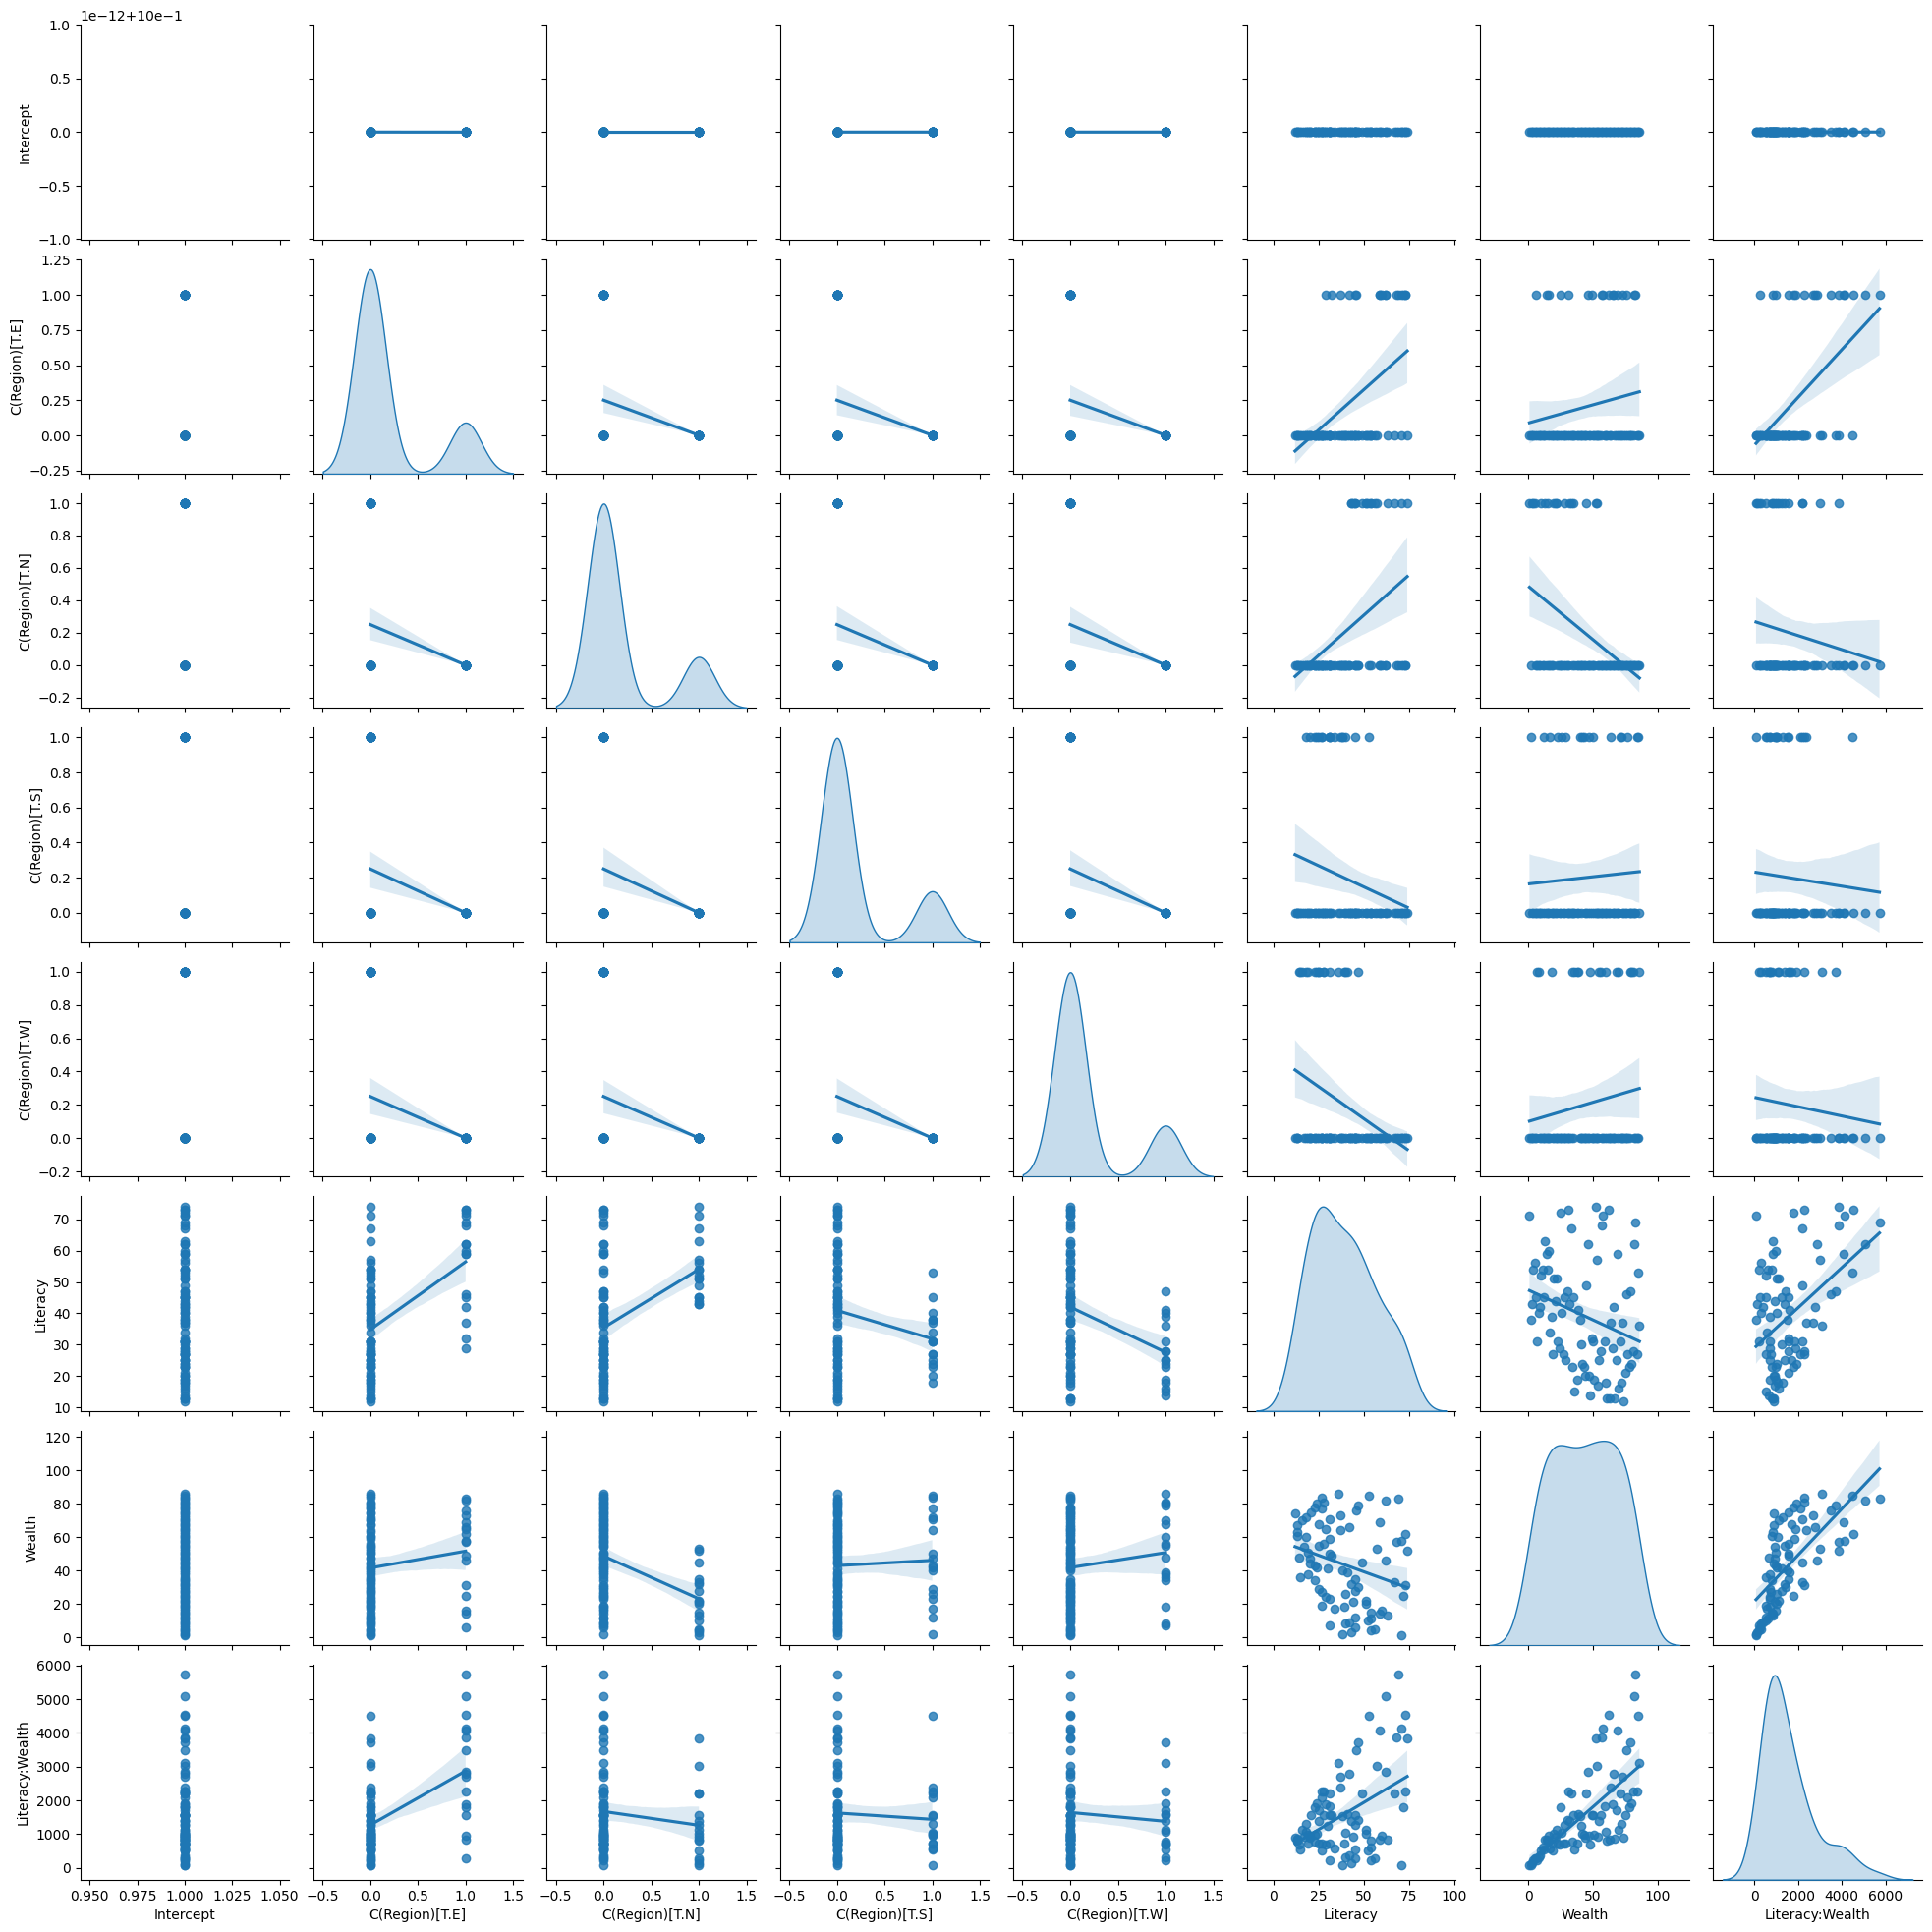

In [248]:
sns.pairplot(data=X, diag_kind="kde", kind="reg")

# Feature analysis and transformation

## Visualize each feature against dependent variable

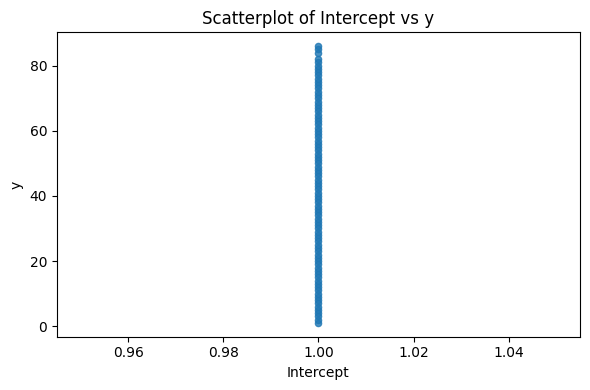

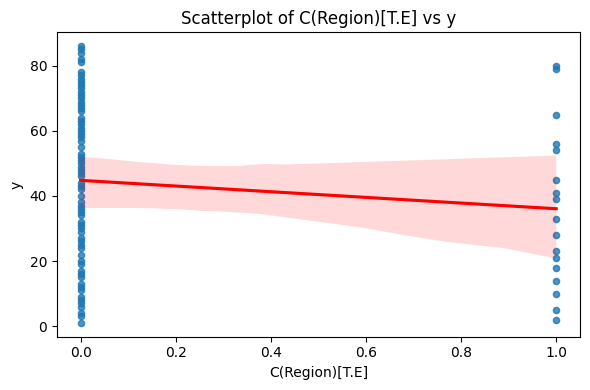

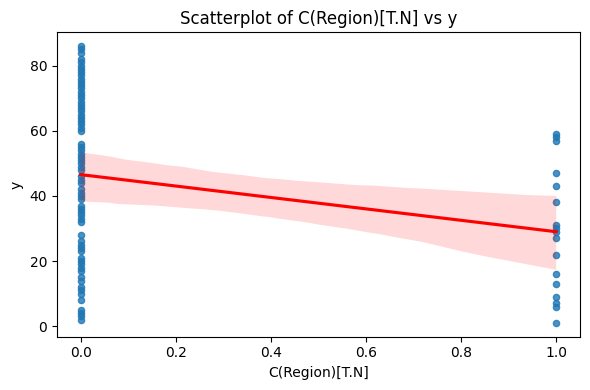

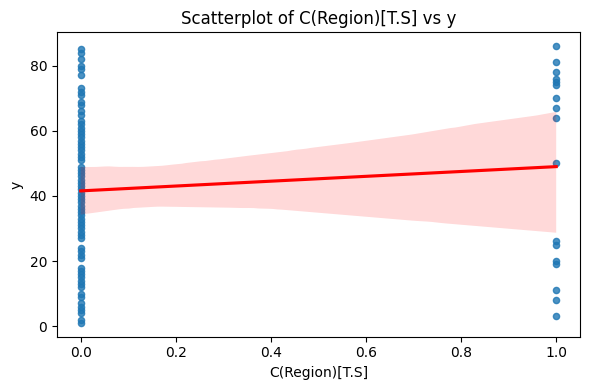

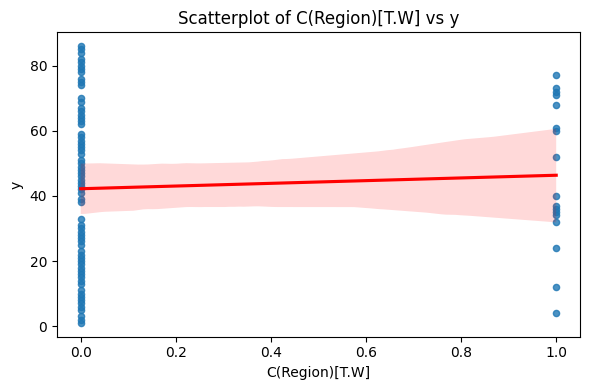

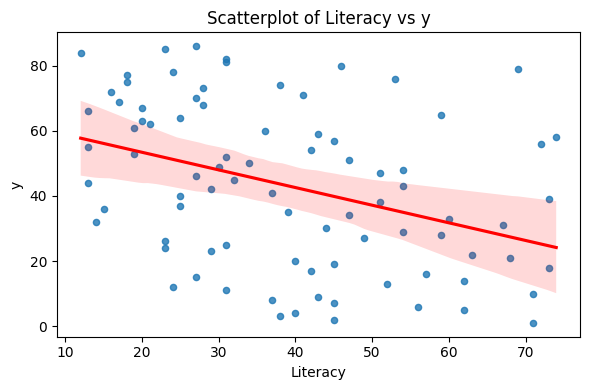

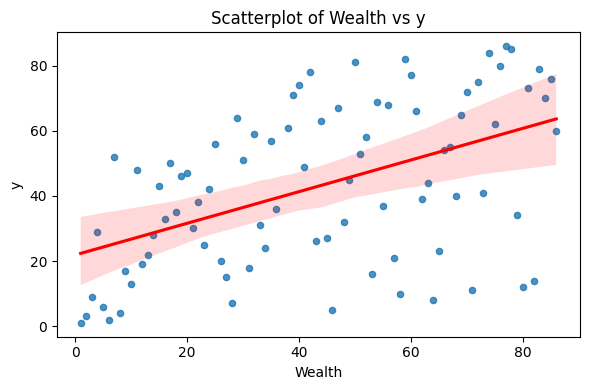

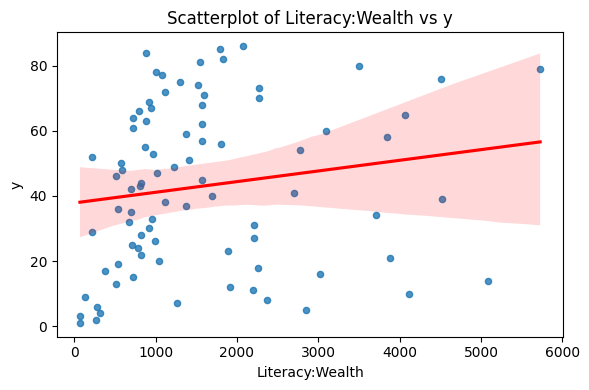

In [249]:
for column in X.columns:
    plt.figure(figsize=(6, 4))
    sns.regplot(x=column, y=y, data=X, ci=99, scatter_kws={"s": 20}, line_kws={"color": "red"})
    plt.title(f'Scatterplot of {column} vs y')
    plt.xlabel(column)
    plt.ylabel('y')
    plt.tight_layout()
    plt.show()

                            OLS Regression Results                            
Dep. Variable:                Lottery   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     14.16
Date:                Thu, 12 Jun 2025   Prob (F-statistic):           0.000312
Time:                        17:34:14   Log-Likelihood:                -386.13
No. Observations:                  85   AIC:                             776.3
Df Residuals:                      83   BIC:                             781.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         64.2389      6.163     10.423      0.0

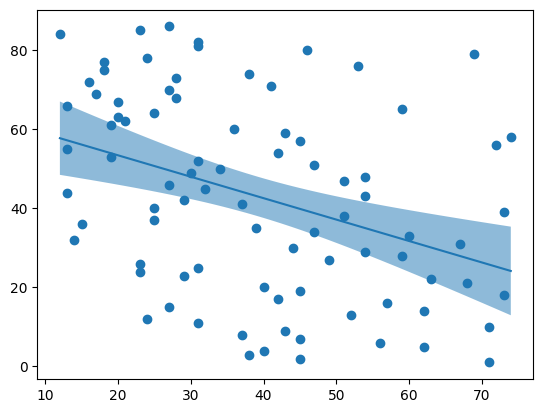

In [67]:
import statsmodels.api as sm


def simple_regplot(
    x, y, n_std=2, n_pts=100, ax=None, scatter_kws=None, line_kws=None, ci_kws=None
):
    """ Draw a regression line with error interval. """
    ax = plt.gca() if ax is None else ax

    # calculate best-fit line and interval
    x_fit = sm.add_constant(x)
    fit_results = sm.OLS(y, x_fit).fit()

    eval_x = sm.add_constant(np.linspace(np.min(x), np.max(x), n_pts))
    pred = fit_results.get_prediction(eval_x)

    # draw the fit line and error interval
    ci_kws = {} if ci_kws is None else ci_kws
    ax.fill_between(
        eval_x[:, 1],
        pred.predicted_mean - n_std * pred.se_mean,
        pred.predicted_mean + n_std * pred.se_mean,
        alpha=0.5,
        **ci_kws,
    )
    line_kws = {} if line_kws is None else line_kws
    h = ax.plot(eval_x[:, 1], pred.predicted_mean, **line_kws)

    # draw the scatterplot
    scatter_kws = {} if scatter_kws is None else scatter_kws
    ax.scatter(x, y, c=h[0].get_color(), **scatter_kws)

    return fit_results

results = simple_regplot(x=X["Literacy"], y=y)
print(results.summary())

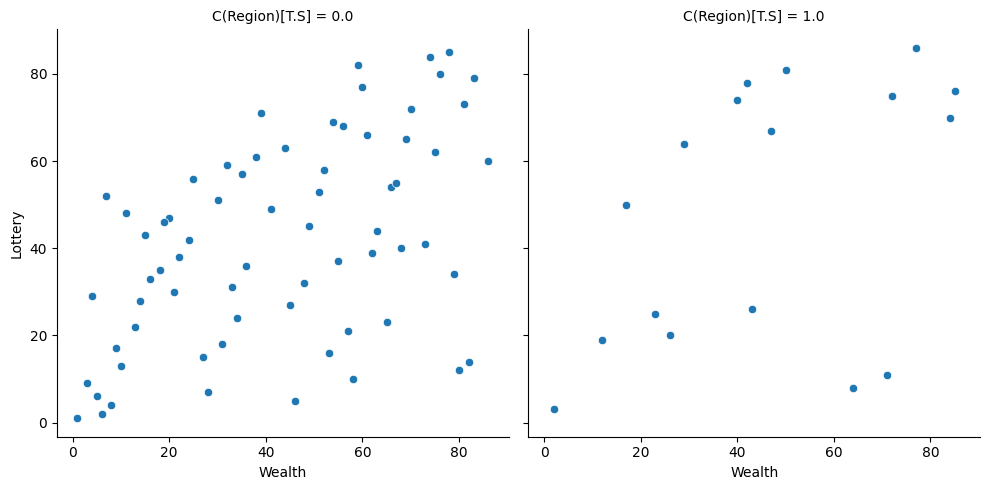

In [ ]:
sns.relplot(data = pd.concat([X, y], axis=1), y = "Lottery", x = "Wealth", kind="scatter", col="C(Region)[T.S]")

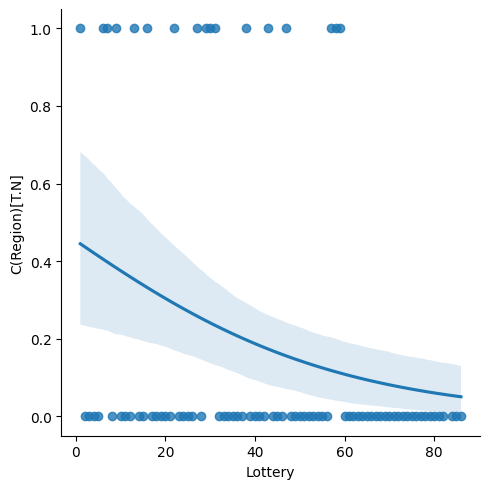

In [51]:
sns.lmplot(data = pd.concat([X, y], axis=1), y = "C(Region)[T.N]", x= "Lottery", logistic=True)

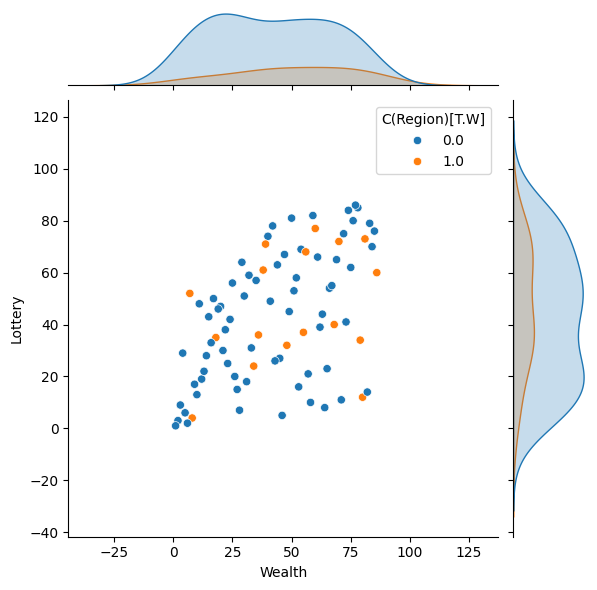

In [52]:
sns.jointplot(data=pd.concat([X, y], axis=1), x="Wealth", y = "Lottery", hue = "C(Region)[T.W]", kind="scatter")

## Compute VIFs among candidate features

### What is VIF?

The **Variance Inflation Factor (VIF)** is a diagnostic measure that quantifies the **severity of multicollinearity** in a regression model. Multicollinearity occurs when two or more independent variables in your model are highly correlated with each other.

* **Definition:** For each independent variable, VIF measures how much the variance of its estimated regression coefficient is "inflated" due to its correlation with the other predictors in the model.
* **Calculation:** For a given predictor $X_i$, its VIF is calculated as:
    $VIF_i = \frac{1}{1 - R_i^2}$
    where $R_i^2$ is the $R^2$ value from a regression of $X_i$ against *all the other* independent variables in the model.

### What do the values tell me?

* **VIF = 1:** Indicates **no multicollinearity** for that specific predictor. The predictor is completely uncorrelated with all other predictors in the model.
* **VIF > 1:** Indicates the presence of multicollinearity.
    * **VIF between 1 and 5:** Generally considered **moderate or acceptable** multicollinearity. The impact on coefficient variance is often not severe.
    * **VIF > 5 (or > 10):** Indicates **severe multicollinearity**. This suggests that the coefficient for this particular predictor is poorly estimated because it's highly redundant with other predictors in the model.

### Why is a High VIF "Bad"?

High VIF for a predictor means:

1.  **Unstable Coefficient Estimates:** Small changes in the data can lead to large, erratic shifts in the estimated coefficient for that predictor. It makes the coefficient unstable and unreliable.
2.  **Inflated Standard Errors:** The standard error of the coefficient is increased, making it harder to find the predictor statistically significant (higher p-values) even if it has a true relationship with the dependent variable.
3.  **Reduced Statistical Power:** It becomes difficult to determine the true individual effect of each highly correlated predictor.

### How to Use VIF?

1.  **Calculate VIF for Each Predictor:** You typically calculate VIF for each independent variable in your model.
2.  **Identify Problematic Predictors:** Look for predictors with VIF values exceeding the chosen threshold (e.g., 5 or 10).
3.  **Investigate:** For predictors with high VIF, examine their correlation with other predictors to identify the specific pairs or groups causing the multicollinearity.

### How to Address a High VIF:

* **Standardize or Center Features:** While VIF itself is scale-invariant, standardizing numerical features *before* fitting the model can sometimes reduce the condition number (a broader multicollinearity indicator) and improve numerical stability, even if it doesn't fundamentally change VIF.
* **Remove Redundant Predictors:** If two or more predictors are highly correlated and one is clearly redundant, consider removing one of them.
* **Combine Correlated Predictors:** Create a composite variable (e.g., average or sum) from highly correlated predictors if their combined effect is meaningful.
* **Principal Component Analysis (PCA):** Transform the set of correlated predictors into a smaller set of uncorrelated principal components.
* **Regularization (Ridge Regression):** L2 (Ridge) regularization specifically handles multicollinearity by shrinking coefficients, which can stabilize estimates, though it doesn't remove predictors.

**Comparison to Condition Number:** Both VIF and the Condition Number diagnose multicollinearity. VIF focuses on the inflation of *individual* coefficient variances due to their correlations with *other predictors*. The Condition Number is a more *overall* measure of the multicollinearity in the entire design matrix, indicating general numerical stability. A high condition number might exist even if individual VIFs are moderate if there are complex relationships among multiple predictors.

---

<Axes: xlabel='VIF', ylabel='feature'>

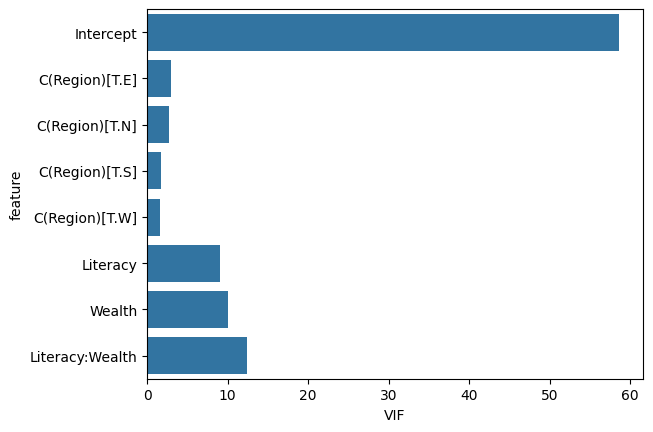

In [251]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

vif_data.head(20)

sns.barplot(data=vif_data, x="VIF", y="feature")

# Standardization

In [252]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_vars = ['Literacy', 'Wealth', "Literacy:Wealth"] # Clearly manually define

X_transformed = pd.concat([X.drop(numerical_vars, axis=1), pd.DataFrame(scaler.fit_transform(X[numerical_vars]), columns=numerical_vars)], axis = 1)

# Specify OLS

## Interaction terms

Think critically about features using domain knowledge.
*What features could have an effect on each other?*

## Model specification and fitting

In [253]:
# With normal SM API
ols = sm.OLS(y, X)
res = ols.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                Lottery   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     5.615
Date:                Mon, 16 Jun 2025   Prob (F-statistic):           2.96e-05
Time:                        09:05:26   Log-Likelihood:                -375.30
No. Observations:                  85   AIC:                             766.6
Df Residuals:                      77   BIC:                             786.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          39.0993     17.470     

In [255]:
ols_std = sm.OLS(y, X_transformed)
res_std = ols_std.fit()
print(res_std.summary())

                            OLS Regression Results                            
Dep. Variable:                Lottery   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     5.615
Date:                Mon, 16 Jun 2025   Prob (F-statistic):           2.96e-05
Time:                        09:05:51   Log-Likelihood:                -375.30
No. Observations:                  85   AIC:                             766.6
Df Residuals:                      77   BIC:                             786.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          51.0564      5.807     

In [ ]:
# With SM formulas API

## Elastic net regularization

In [262]:
ols_reged = ols_std.fit_regularized(alpha=0.5, L1_wt=1, refit=True, maxiter=1000)
print(ols_reged.summary())

                            OLS Regression Results                            
Dep. Variable:                Lottery   R-squared:                       0.328
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     7.806
Date:                Mon, 16 Jun 2025   Prob (F-statistic):           5.04e-06
Time:                        09:06:46   Log-Likelihood:                -375.94
No. Observations:                  85   AIC:                             763.9
Df Residuals:                      80   BIC:                             778.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          46.0072      2.994     

In [57]:
print(X_transformed.head())

   Intercept  C(Region)[T.E]  C(Region)[T.N]  C(Region)[T.S]  C(Region)[T.W]  Literacy    Wealth
0        1.0             1.0             0.0             0.0             0.0 -0.123543  1.178832
1        1.0             0.0             1.0             0.0             0.0  0.684236 -0.864445
2        1.0             0.0             0.0             0.0             0.0 -1.508306  0.698061
3        1.0             1.0             0.0             0.0             0.0  0.395744  1.299024
4        1.0             1.0             0.0             0.0             0.0  1.722809  1.579474


# OLS Model interpretation

In [263]:
ols_std = sm.OLS(y, X_transformed.drop("C(Region)[T.S]", axis=1))
res_std = ols_std.fit(cov_type="HC1")
print(res_std.summary())

                            OLS Regression Results                            
Dep. Variable:                Lottery   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.283
Method:                 Least Squares   F-statistic:                     7.612
Date:                Mon, 16 Jun 2025   Prob (F-statistic):           1.90e-06
Time:                        09:06:56   Log-Likelihood:                -375.51
No. Observations:                  85   AIC:                             765.0
Df Residuals:                      78   BIC:                             782.1
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          48.5622      4.434     

## F-statistic for model significance

### What is the F-Statistic?

The **F-statistic** (and its associated p-value, `Prob(F-statistic)`) in a `statsmodels` OLS summary is a test for the **overall statistical significance of your regression model**.

It addresses the fundamental question: **Are *all* the independent variables in your model (taken together) jointly significant in explaining the variation in the dependent variable, or could the observed relationship simply be due to random chance?**

* **Null Hypothesis ($H_0$):** All the regression coefficients (excluding the intercept) are simultaneously equal to zero. (This implies that none of the independent variables have a statistically significant linear relationship with the dependent variable).
* **Alternative Hypothesis ($H_A$):** At least one of the regression coefficients is not equal to zero. (This implies that the model, as a whole, provides a better explanation of the variation in the dependent variable than a model with no independent variables).

The F-statistic is essentially a ratio of the variance explained by your model to the unexplained variance (error variance).

### What do the values tell me?

* **High F-Statistic:** A larger F-statistic value indicates that the variance explained by your model is much greater than the unexplained variance. This suggests that your model is doing a good job of explaining the variability in the dependent variable.
* **Low `Prob(F-statistic)` (p-value, e.g., < 0.05):**
    * You **reject the null hypothesis**.
    * This is the desired outcome. It means that your model, as a whole, is **statistically significant**. You can conclude that at least one of the independent variables in your model has a significant relationship with the dependent variable.
* **High `Prob(F-statistic)` (p-value, e.g., > 0.05):**
    * You **fail to reject the null hypothesis**.
    * This suggests that your model, as a whole, is **not statistically significant**. This implies that the independent variables, *taken together*, do not provide a better explanation of the dependent variable's variation than simply using the mean of the dependent variable.

### Numerical Score (Good or Bad):

* There isn't a "good" or "bad" absolute numerical value for the F-statistic itself, as it depends on the number of predictors and observations.
* The **p-value (`Prob(F-statistic)`) is what you should focus on.**
    * **Good:** A p-value **less than your chosen significance level** (e.g., `< 0.05`) is good, indicating overall model significance.
    * **Bad:** A p-value **greater than your chosen significance level** (`> 0.05`) suggests the model is not statistically significant.

### How does it compare to other metrics and how do I compare models?

* **Overall Model Significance vs. Individual Predictor Significance:**
    * The F-statistic tells you about the model *as a whole*.
    * The t-statistics and their p-values for individual coefficients tell you if *each specific independent variable* is significant, holding others constant.
    * It's possible to have a significant F-statistic (overall model is useful) but no individually significant predictors (perhaps due to multicollinearity where variables are jointly significant but not uniquely so).
* **F-statistic vs. R-squared:**
    * **R-squared** tells you the *proportion* of variance in the dependent variable that your model explains. It's a measure of explanatory power or "goodness of fit."
    * The **F-statistic** provides a *hypothesis test* for whether that explained variance (R-squared) is statistically significant, i.e., unlikely to have occurred by chance. A higher R-squared generally leads to a higher F-statistic.
* **Model Comparison:**
    * The F-statistic is specifically for testing the overall significance of *your model* against a null model (one with only an intercept).
    * For comparing different non-nested models, you'd typically look at metrics like **Adjusted R-squared, AIC, or BIC**, which penalize for complexity and are better suited for model selection. For nested models (where one model is a subset of another), you can use an F-test to compare them directly.

**In essence:** The F-statistic is your initial sanity check. If it's not significant, it suggests your model isn't doing a better job at explaining the dependent variable than simply guessing its mean, and you should reconsider your predictors.

---

## Omnibus value and P(omnibus) for residual evaluation



### What are they?

These values are diagnostics within the `statsmodels` OLS summary table, typically found under "Diagnostics". They relate to the **normality of the model's residuals**.

* **Omnibus:** This is the test statistic for the **D'Agostino-Pearson's omnibus test**. This test combines skewness and kurtosis tests to provide an overall assessment of whether the residuals follow a normal distribution. A higher Omnibus value indicates a greater deviation from normality.
* **Prob(Omnibus):** This is the **p-value** associated with the Omnibus test statistic.

### What do the values tell me?

* **Null Hypothesis ($H_0$):** The residuals are normally distributed.
* **Alternative Hypothesis ($H_A$):** The residuals are NOT normally distributed.

* **Low `Prob(Omnibus)` (e.g., < 0.05):**
    * You **reject the null hypothesis**.
    * This suggests that the model's residuals are **NOT normally distributed**.
    * This is a violation of a key assumption for classical OLS inference (though OLS estimates themselves are robust to non-normality with large samples, standard errors and p-values can be affected).

* **High `Prob(Omnibus)` (e.g., > 0.05):**
    * You **fail to reject the null hypothesis**.
    * This suggests that there is **not enough evidence to conclude that the residuals are non-normal**. They are consistent with a normal distribution.
---

## Jarque-Bera and P(Jarque-Bera) for residual evaluation (basically the same as Omnibus)

### What are Jarque-Bera (JB) and Prob(Jarque-Bera)?

The **Jarque-Bera (JB) test** is another statistical test used to assess whether sample data (often, the residuals from a regression model) have the **skewness and kurtosis that match a normal distribution**.

* **JB Statistic:** This is the test statistic. It's calculated based on the sample's skewness (a measure of asymmetry) and kurtosis (a measure of the "tailedness" or peakiness compared to a normal distribution).
    * A normal distribution has a skewness of 0 and an **excess kurtosis** of 0 (or a raw kurtosis of 3).
    * The JB statistic will be higher if the sample's skewness deviates from 0 or its kurtosis deviates from 3.
* **Prob(Jarque-Bera):** This is the **p-value** associated with the Jarque-Bera test statistic.

### What do the values tell me?

* **Null Hypothesis ($H_0$):** The data (e.g., residuals) are normally distributed (i.e., skewness is 0 and excess kurtosis is 0).
* **Alternative Hypothesis ($H_A$):** The data are NOT normally distributed.

* **Low `Prob(Jarque-Bera)` (e.g., < 0.05):**
    * You **reject the null hypothesis**.
    * This suggests that the data are **NOT normally distributed**, typically due to significant skewness and/or kurtosis different from that of a normal distribution.

* **High `Prob(Jarque-Bera)` (e.g., > 0.05):**
    * You **fail to reject the null hypothesis**.
    * This suggests that there is **not enough evidence to conclude that the data are non-normal**. They are consistent with a normal distribution.

### What numerical score is good or bad?

* The **JB statistic itself is always non-negative**. A value of 0 indicates perfect normality in terms of skewness and kurtosis.
* **Good:** A `Prob(Jarque-Bera)` value **above your chosen significance level** (e.g., > 0.05) is considered "good," as it means your residuals' shape is consistent with normality.
* **Bad:** A `Prob(Jarque-Bera)` value **below your chosen significance level** (e.g., < 0.05) indicates non-normality.

### How does it compare to Omnibus?

In the `statsmodels` OLS summary:

* The `Omnibus` test (which uses D'Agostino-Pearson's omnibus test) and the `Jarque-Bera` test are **both tests for normality of residuals**.
* **They are often very similar or even the exact same test.** In many statistical packages, including `statsmodels`, the "Omnibus" entry *is* the D'Agostino-Pearson test, which is itself an omnibus test combining skewness and kurtosis, similar in spirit to Jarque-Bera.
* **The key difference lies in the specific formula and underlying statistical theory.** While both rely on skewness and kurtosis, their exact calculations and asymptotic properties (how their test statistic behaves for very large samples) can differ slightly.
* **Practical Outcome:** In practice, for most standard regression analyses, if one test indicates non-normality, the other likely will too. They generally lead to the same conclusions regarding the normality assumption.

**Like the Omnibus test, Jarque-Bera is a diagnostic for an assumption, not a measure of model fit.** It's used to check if your residuals are normally distributed, which affects the validity of classical OLS inference (p-values, confidence intervals). Do not use it to compare overall model performance (use R-squared, AIC, BIC, etc. for that).

---

## Durbin-Watson statistic for autocorrelation

### What is the Durbin-Watson Statistic?

The **Durbin-Watson (DW) statistic** is a test statistic used to detect the presence of **first-order autocorrelation (or serial correlation)** in the residuals (errors) of a regression model.

* **Autocorrelation:** Occurs when the residuals are not independent of each other. This often happens with **time series data** where the error at one point in time is correlated with the error at the next point in time.
* **Why it matters:** If residuals are autocorrelated, it violates a key assumption of Ordinary Least Squares (OLS) regression. This can lead to:
    * **Biased standard errors:** Making your p-values unreliable (you might incorrectly find variables significant or insignificant).
    * **Inefficient coefficient estimates:** Though still unbiased, they won't be the "best" estimates.
    * **Invalid hypothesis tests:** Affecting the reliability of your statistical inferences.

The DW statistic is approximately equal to $2(1 - r)$, where $r$ is the sample autocorrelation of the residuals at lag 1.

### What do the values tell me?

The Durbin-Watson statistic always ranges between **0 and 4**.

* **DW $\approx 2$:** Indicates **no autocorrelation** in the residuals. This is the ideal scenario, meaning the residuals are independent.
* **DW $< 2$:** Suggests **positive autocorrelation**. This means consecutive residuals tend to have the same sign (positive error followed by positive error, or negative by negative). This is common in time series where trends are not fully captured. The closer to 0, the stronger the positive autocorrelation.
* **DW $> 2$:** Suggests **negative autocorrelation**. This means consecutive residuals tend to have alternating signs (positive error followed by negative error, or vice-versa). This is less common but can occur if the model "over-corrects" for trends. The closer to 4, the stronger the negative autocorrelation.

### What numerical score is good or bad?

* **Good:** A value **around 2** (typically between **1.5 and 2.5** as a rough rule of thumb) is generally considered acceptable, indicating no significant first-order autocorrelation.
* **Bad:**
    * Values **significantly less than 1.5** (closer to 0) indicate problematic positive autocorrelation.
    * Values **significantly greater than 2.5** (closer to 4) indicate problematic negative autocorrelation.

### Critical Values & Formal Testing:

While the 1.5-2.5 rule of thumb is common, a more rigorous test involves comparing the DW statistic to specific **lower ($d_L$) and upper ($d_U$) critical values**. These critical values depend on:
* The sample size ($n$)
* The number of independent variables ($k$) in your model.

You'd typically look these up in a Durbin-Watson critical values table (or statistical software might provide a p-value for the test).

* If $DW < d_L$: Significant positive autocorrelation.
* If $DW > 4 - d_L$: Significant negative autocorrelation.
* If $d_U < DW < 4 - d_U$: No autocorrelation.
* If $d_L \leq DW \leq d_U$ or $4 - d_U \leq DW \leq 4 - d_L$: Inconclusive region.

---

## Condition number for multicollinearity

### What is the Condition Number?

The **Condition Number** in a `statsmodels` OLS summary is a diagnostic measure for **multicollinearity** and potential **numerical problems** in your regression model.

* **Definition:** It's calculated as the ratio of the largest to the smallest singular value of the design matrix (X) used in the regression. In simpler terms, it reflects the "spread" or "range" of your independent variables' values.
* **Sensitivity to Input:** A high condition number indicates that your regression estimates (the coefficients) are **highly sensitive to small changes or errors in the input data**. This means small variations in your predictor variables could lead to large changes in your estimated coefficients, making them unstable.

### What do the values tell me?

The condition number helps you assess the severity of multicollinearity:

* **Low Condition Number (e.g., < 10):** Generally indicates **weak or no multicollinearity**. The model is numerically stable, and coefficient estimates are robust to minor data perturbations.
* **Moderate Condition Number (e.g., between 10 and 30):** Suggests **moderate multicollinearity**. While not always problematic, it's worth noting.
* **High Condition Number (e.g., > 30):** Indicates **severe multicollinearity**. This is often accompanied by the `statsmodels` warning: "The condition number is large... This might indicate that there are strong multicollinearity or other numerical problems."

### Why is a High Condition Number "Bad"?

A high condition number signifies:

1.  **Unstable Coefficient Estimates:** Small changes in data points or even rounding errors can lead to drastically different coefficient values. This makes the interpretation of individual coefficients unreliable.
2.  **Inflated Standard Errors:** Multicollinearity inflates the standard errors of the affected coefficients, making them appear statistically insignificant (high p-values) even if the variables are truly related to the response.
3.  **Difficulty in Interpretation:** It becomes hard to isolate the unique effect of each highly correlated predictor.

### How to Address a High Condition Number:

* **Standardize or Center Features:** `statsmodels` calculates the condition number on the non-standardized design matrix. **Scaling or centering your numerical independent variables** (especially if they are on very different scales or far from zero) often significantly reduces the condition number and can resolve numerical stability issues, even if true multicollinearity isn't present. This is typically the first step.
* **Remove Redundant Predictors:** If two or more predictors are highly correlated (e.g., VIF > 5 or 10), consider removing one of them if they convey very similar information.
* **Combine Correlated Predictors:** Create a composite variable from highly correlated predictors (e.g., an average or sum).
* **Principal Component Analysis (PCA):** Transform correlated predictors into a set of uncorrelated principal components.
* **Regularization Techniques:** Methods like Ridge Regression (L2 regularization) can mitigate the effects of multicollinearity by shrinking coefficients, but they don't solve the underlying data issue.

**In summary:** The condition number is a crucial diagnostic. A high value warns you that your model's coefficient estimates might be unstable and unreliable due to strong relationships among your independent variables, and that data scaling could be a factor.

---

# Time series modelling

In [82]:
df2 = sm.datasets.get_rdataset(dataname="CO2", package="datasets").data
df2.head(20)
df2.dtypes

time     float64
value    float64
dtype: object

<Axes: xlabel='time', ylabel='value'>

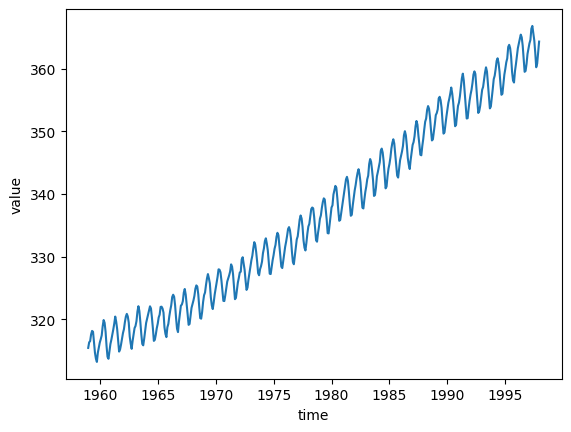

In [92]:
sns.lineplot(df2, x="time", y="value")

<Axes: xlabel='time', ylabel='value'>

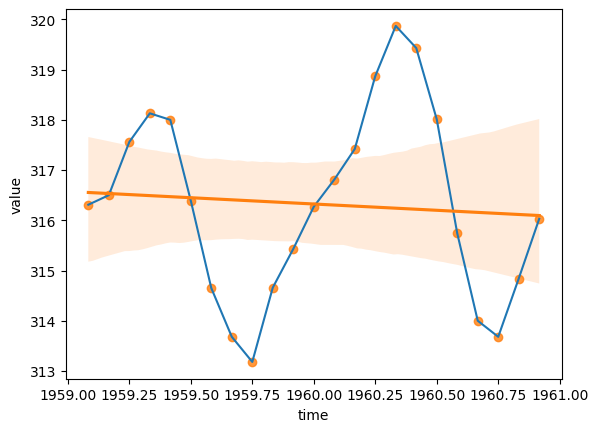

In [90]:
sns.lineplot(df2, x=df2.iloc[1:24,0], y=df2.iloc[1:24,1])
sns.regplot(df2, x=df2.iloc[1:24,0], y=df2.iloc[1:24,1])

In [97]:
import numpy as np
df2['year']=np.floor(df2['time'])

In [117]:
OLS = sm.OLS(df2['value'], sm.add_constant(df2['time'])).fit()
print(OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                 1.479e+04
Date:                Fri, 13 Jun 2025   Prob (F-statistic):               0.00
Time:                        15:58:56   Log-Likelihood:                -1113.5
No. Observations:                 468   AIC:                             2231.
Df Residuals:                     466   BIC:                             2239.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2249.7742     21.268   -105.784      0.0

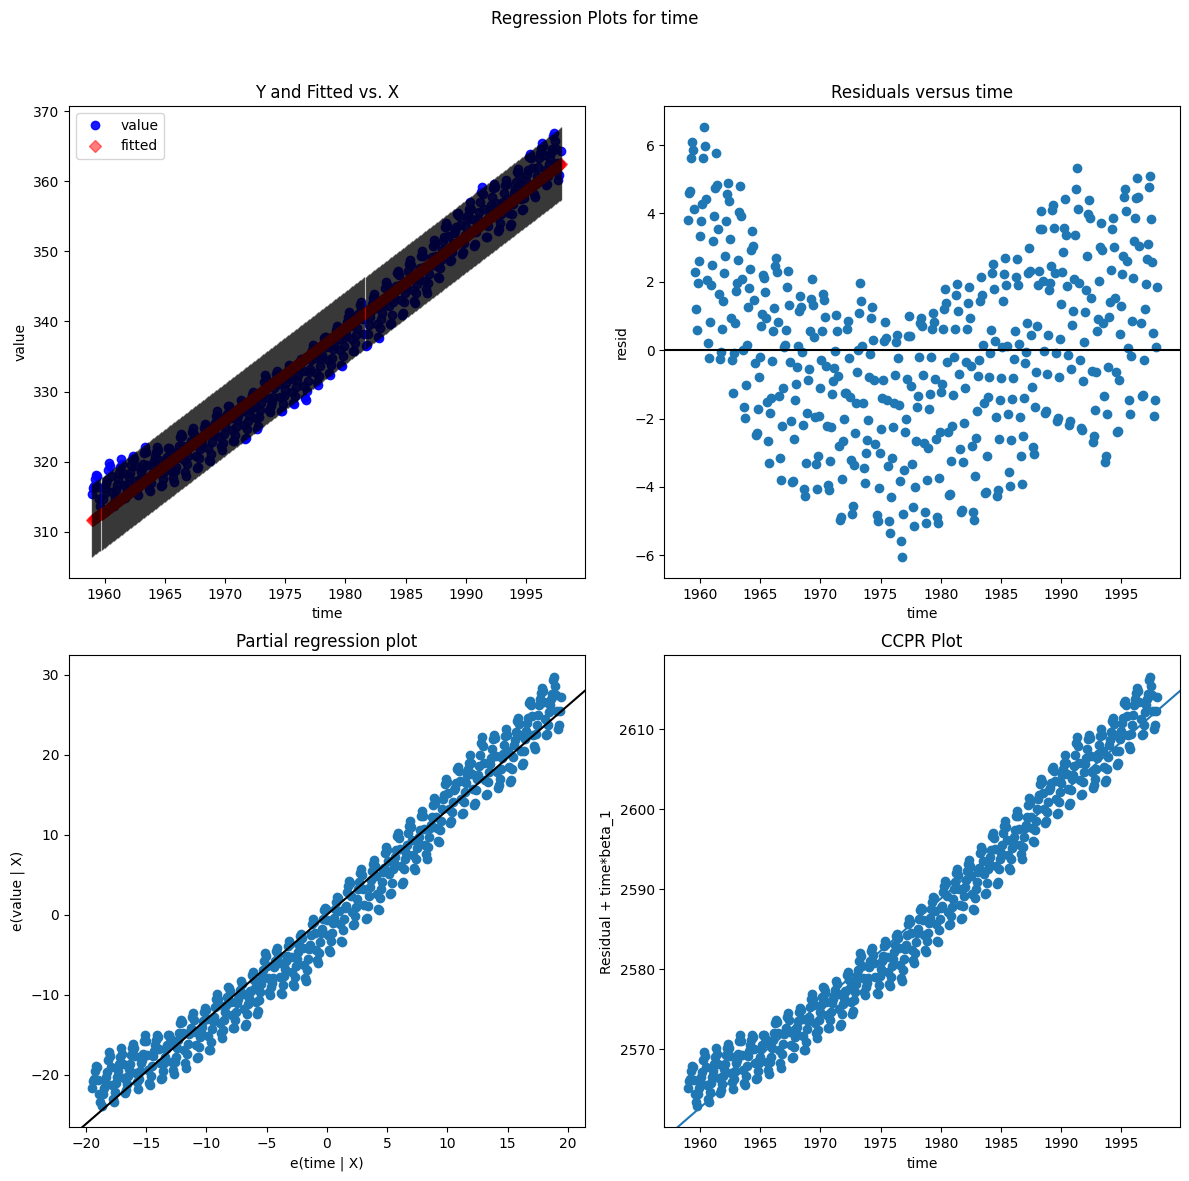

In [116]:
fig = plt.figure(figsize=(12, 12))
fig = sm.graphics.plot_regress_exog(OLS, "time", fig=fig)

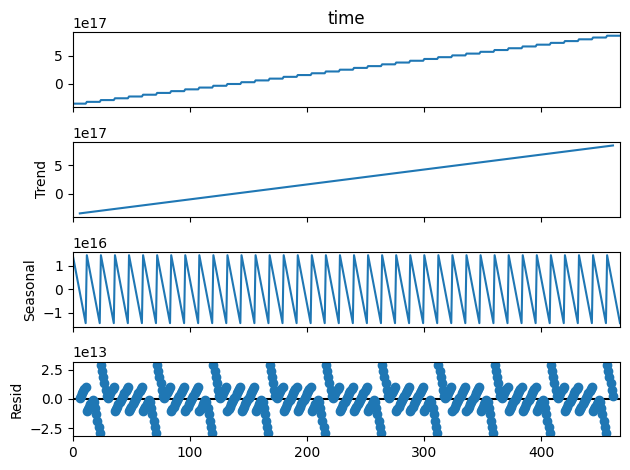

In [125]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Convert decimal year time to datetime
# Understand that time is a decimal year value
df2['time'] = pd.to_datetime(df2['year'], format='%Y')
decomposition = seasonal_decompose(df2['time'], period=12, model="additive")
fig=decomposition.plot()

In [126]:
df2['time']

0     1959-01-01
1     1959-01-01
2     1959-01-01
3     1959-01-01
4     1959-01-01
         ...    
463   1997-01-01
464   1997-01-01
465   1997-01-01
466   1997-01-01
467   1997-01-01
Name: time, Length: 468, dtype: datetime64[ns]

# GAM model setup

In [ ]:
wage = sm.datasets.get_rdataset("Wage", "ISLR").data
wage

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


<Axes: xlabel='age', ylabel='wage'>

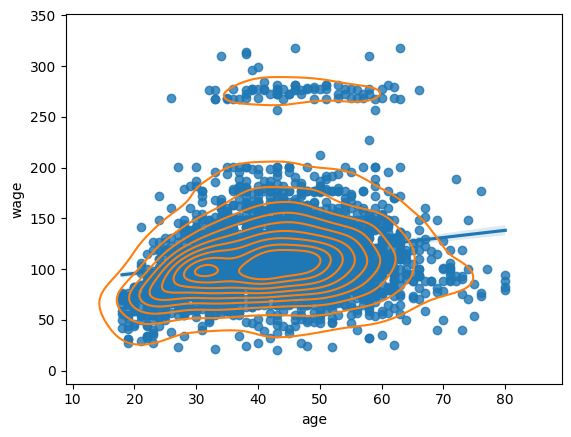

In [175]:
sns.regplot(wage, x="age", y="wage")
sns.kdeplot(wage, x= "age", y="wage")

## Map ordinal variables

In [202]:
# Dirty way
wage['health']= wage['health'].astype(str).str[0].astype(int)
wage['education']=wage['education'].astype(str).str[0].astype(int)

In [205]:
wage.drop("region", inplace=True, axis=1)

In [ ]:
wage

In [207]:
numerical = wage.select_dtypes(['number']).columns.to_list()
categorical = wage.select_dtypes(exclude="number").columns.to_list()
print(numerical, categorical)

['year', 'age', 'education', 'health', 'logwage', 'wage'] ['maritl', 'race', 'jobclass', 'health_ins']


In [208]:
from patsy import dmatrices

y, X = dmatrices("wage~year+age+C(maritl)+C(race)+education+C(jobclass)+health+C(health_ins)", data=wage, return_type="dataframe")

In [209]:
X = X.reset_index().drop("rownames", axis=1)
y=y.reset_index().drop("rownames", axis=1)

<Axes: ylabel='Density'>

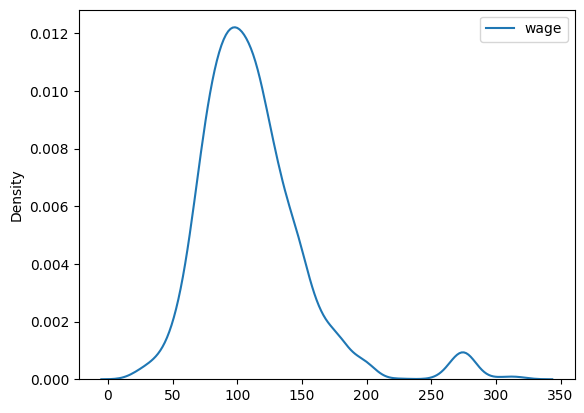

In [216]:
sns.kdeplot(y)

<Axes: xlabel='VIF', ylabel='feature'>

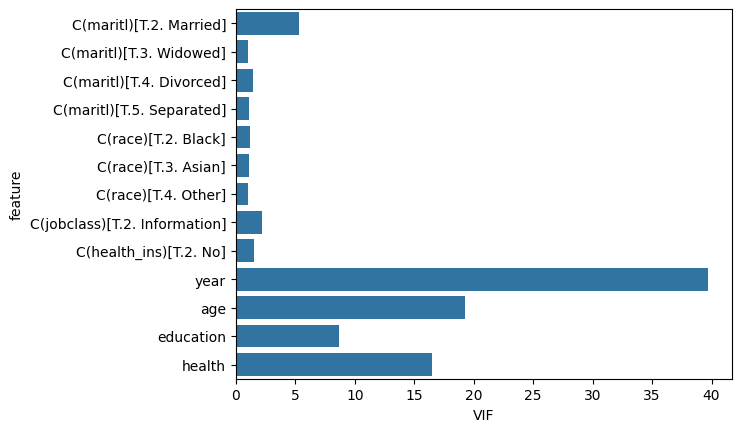

In [210]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.drop("Intercept", axis=1).columns
vif_data["VIF"] = [variance_inflation_factor(X.drop("Intercept", axis=1).values, i)
                   for i in range(X.drop("Intercept", axis=1).shape[1])]

vif_data.head(20)
sns.barplot(data=vif_data, x="VIF", y="feature")

In [211]:
glm_wage = sm.GLM(y, X).fit()
glm_wage.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                   wage   No. Observations:                 3000
Model:                            GLM   Df Residuals:                     2986
Model Family:                Gaussian   Df Model:                           13
Link Function:               Identity   Scale:                          1166.9
Method:                          IRLS   Log-Likelihood:                -14843.
Date:                Fri, 13 Jun 2025   Deviance:                   3.4844e+06
Time:                        16:48:27   Pearson chi2:                 3.48e+06
No. Iterations:                     3   Pseudo R-squ. (CS):             0.3913
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                     -2506.9930    619.205     -4.049      0.000   -3720.612   -1293.374
C(maritl)[T.2. Married]          17.4337      1.728     10.091      0.000      14.048      20.820
C(maritl)[T.3. Widowed]           2.1367      8.041      0.266      0.790     -13.623      17.896
C(maritl)[T.4. Divorced]          3.8366      2.899      1.323      0.186      -1.846       9.519
C(maritl)[T.5. Separated]        12.1196      4.861      2.493      0.013       2.592      21.647
C(race)[T.2. Black]              -5.3333      2.149     -2.482      0.013      -9.545      -1.122
C(race)[T.3. Asian]              -1.8211      2.604     -0.699      0.484      -6.926       3.284
C(race)[T.4. Other]              -4.8423      5.684     -0.852      0.394     -15.982       6.298
C(jobclass)[T.2. Information]     3.8755      1.329      2.917      0.004       1.272       6.479
C(health_ins)[T.2. No]          -17.0666      1.406    -12.135      0.000     -19.823     -14.310
year                              1.2696      0.309      4.112      0.000       0.664       1.875
age                               0.2899      0.062      4.650      0.000       0.168       0.412
education                        13.3077      0.565     23.563      0.000      12.201      14.415
health                            6.5726      1.427      4.605      0.000       3.775       9.370
=================================================================================================
"""

/var/folders/ll/2dw3c8w16bq4l6d2zkwh1ct40000gn/T/ipykernel_26983/597218005.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


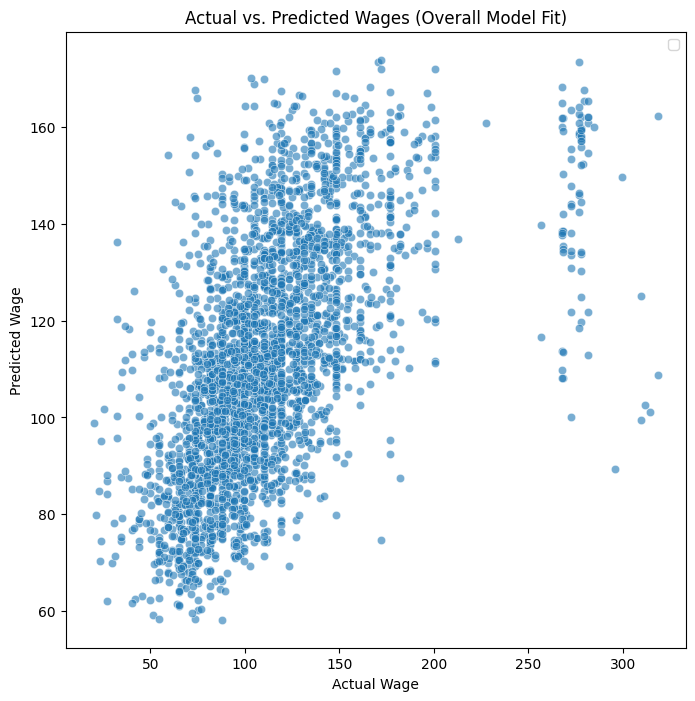

In [241]:
glm_wage_tweedie = sm.GLM(y, X, family=sm.families.Tweedie(var_power=1)).fit()
glm_wage_tweedie.summary()
predictions = glm_wage_tweedie.predict(X)

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y.squeeze(), y=predictions, alpha=0.6)
plt.xlabel('Actual Wage')
plt.ylabel('Predicted Wage')
plt.title('Actual vs. Predicted Wages (Overall Model Fit)')
plt.legend()
plt.show()

In [214]:
glm_wage_reg =  sm.GLM(y, X).fit_regularized(L1_wt=0.9, alpha=0.01, maxiter=5000)
glm_wage_reg.params

Intercept                         0.000000
C(maritl)[T.2. Married]          15.921637
C(maritl)[T.3. Widowed]           0.000000
C(maritl)[T.4. Divorced]          0.000000
C(maritl)[T.5. Separated]         9.931118
C(race)[T.2. Black]              -5.028266
C(race)[T.3. Asian]               0.000000
C(race)[T.4. Other]              -3.652283
C(jobclass)[T.2. Information]     3.744903
C(health_ins)[T.2. No]          -16.986216
year                              0.019543
age                               0.329967
education                        13.288144
health                            6.555541
dtype: float64

In [182]:
gam = sm.GLMGam(y, X)

AttributeError: 'NoneType' object has no attribute 'k_variables'

# GAM model interpretation

# Outlier treatment after model fit

In [58]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns # For example dataset

# Get influence measures
influence = ols_reged.get_influence()

# Create a DataFrame of influence statistics for easier viewing
# These include Cook's Distance, DFFITS, DFBETAS, hat values, and standardized residuals
influence_df = influence.summary_frame()

print("\n--- Top 5 Most Influential Observations (by Cook's Distance) ---")
# Sort by Cook's distance in descending order
print(influence_df.sort_values('cooks_d', ascending=False).head().to_string(line_width = 250))



--- Top 5 Most Influential Observations (by Cook's Distance) ---
    dfb_Intercept  dfb_C(Region)[T.E]  dfb_C(Region)[T.N]  dfb_C(Region)[T.S]  dfb_C(Region)[T.W]  dfb_Literacy  dfb_Wealth   cooks_d  standard_resid  hat_diag  dffits_internal  student_resid    dffits
63      -0.638273            0.413603            0.300903                 inf            0.401697     -0.167338   -0.342853  0.074980       -2.573942  0.073407        -0.724472      -2.652153 -0.746485
41      -0.595343            0.370966            0.247739                 inf           -0.110748     -0.107673   -0.375616  0.070876       -2.414220  0.078445        -0.704368      -2.483213 -0.724497
79      -0.730686            0.508591            0.415415                 inf            0.404402     -0.301547   -0.280493  0.068625       -2.501396  0.071300        -0.693092      -2.571682 -0.712567
49      -0.441503            0.449822            0.125659                 inf            0.366186      0.125745   -0.201330  0

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:929: RuntimeWarning: divide by zero encountered in divide
  dfbetas /= np.sqrt(np.diag(self.results.normalized_cov_params))


## Outlier identification with common methods

## Cooks distance


### What is Cook's Distance?

**Cook's Distance ($D_i$)** measures how much a regression model's **coefficients ($\beta$ values) would change** if a specific observation ($i$) were removed from the dataset. It's a key diagnostic for identifying **influential observations**.

It combines two concepts:
* **Leverage (Hat value):** How "unusual" an observation's predictor (X) values are.
* **Studentized Residual:** How much an observation's response (Y) deviates from its prediction, considering its leverage.

A point needs both **high leverage** and a **large residual** to have a high Cook's Distance.

### When to Use It?

Use Cook's Distance **after fitting a regression model** to:

1.  **Identify Influential Points:** Pinpoint individual data points that disproportionately impact your model's coefficients.
2.  **Assess Model Robustness:** Understand how sensitive your model's results are to single observations.
3.  **Guide Investigation:** Flag points for further review. Is it a data entry error? A measurement issue? Or a genuinely unique, valid observation that reveals something important?

### Interpretation & Thresholds:

While no rule is absolute, common thresholds for $D_i$ are:

* **$D_i > 1$:** Generally considered highly influential.
* **$D_i > \frac{4}{n}$ (where $n$ is the number of observations):** A widely used guideline, especially for larger datasets.

Always complement numerical thresholds with **visual inspection** (e.g., Cook's Distance plots, leverage vs. residual plots) to spot outliers that stand out.

### What to Do with Influential Observations:

**Do NOT simply remove them without careful justification!**

1.  **Verify Data:** Always check for data entry or measurement errors first.
2.  **Consider Robust Methods:** If the observation is valid but truly extreme, use **robust regression methods** (like `statsmodels.RLM`) that are less sensitive to outliers.
3.  **Model Re-evaluation:** The outlier might signal issues with your model specification (e.g., missing variables, uncaptured non-linearity).
4.  **Document & Compare:** If removal is necessary, clearly state your reasons and compare model results with and without the excluded data to show its impact.

---

In [59]:
# a) Cook's Distance:
# Measures how much the regression coefficients change if the observation is removed.
# A common rule of thumb is that values > 4/n (where n is number of observations)
# or sometimes > 1 are considered influential.
cooks_threshold = 4 / len(y)
print(f"\nCook's Distance threshold (4/n): {cooks_threshold:.4f}")
influential_cooks = influence_df[influence_df['cooks_d'] > cooks_threshold]
print(f"Number of observations with Cook's Distance > {cooks_threshold:.4f}: {len(influential_cooks)}")
print(f"Indices: {influential_cooks.index.tolist()}")



Cook's Distance threshold (4/n): 0.0471
Number of observations with Cook's Distance > 0.0471: 3
Indices: [41, 63, 79]


## Hat values / leverage



### What are Leverage (Hat Values)?

**Leverage**, often denoted as $h_{ii}$ (the $i$-th diagonal element of the hat matrix, $H = X(X'X)^{-1}X'$), measures how "unusual" an individual observation's **predictor (X) values** are compared to the overall distribution of predictor values in the dataset.

* **High Leverage:** An observation with high leverage has predictor values that are far away from the average of the predictors. It sits "alone" in the X-space.
* **Geometric Interpretation:** High leverage points are located at the "extremes" of the predictor space. They have the potential to exert a strong pull on the regression line/plane, but they don't necessarily do so unless they also have a large residual.

### When to Use It?

Use Leverage diagnostics **after fitting a regression model** to:

1.  **Identify Outliers in X-space:** Pinpoint observations that have unusual combinations of predictor values.
2.  **Flag Potentially Influential Points:** High leverage points are "potential" influencers. They have the capacity to pull the regression line towards themselves.
3.  **Guide Investigation:** Examine high-leverage points for data errors or unique characteristics.

### Interpretation & Thresholds:

Leverage values range from $0$ to $1$.

Common rules of thumb for identifying high leverage:

* **$h_{ii} > \frac{2(p+1)}{n}$:** (where $p$ is the number of predictors, $n$ is number of observations). Points exceeding this are often considered high leverage.
* **$h_{ii} > \frac{3(p+1)}{n}$:** A more conservative threshold.
* **Visual Inspection:** Look for points that stand out in scatter plots of predictors or on influence plots.

### What to Do with High Leverage Observations:

**High leverage alone does NOT mean an observation is problematic or should be removed.**

* **Investigate First:** Always check high-leverage points for data errors or unusual circumstances.
* **Context is Key:** A valid high-leverage point might be crucial for understanding the model's behavior at the extremes of your predictor range.
* **Consider Influence:** While high leverage indicates *potential* influence, it doesn't guarantee it. A high leverage point might still fall perfectly on the regression line (small residual), in which case it has low influence (low Cook's Distance).
* **Robust Methods:** If high-leverage points are also influential (high Cook's Distance), consider robust regression methods as an alternative to removal.



In [60]:
# b) Leverage (Hat values):
# Measures how far an observation's predictor values are from the average of the predictors.
# Rule of thumb: values > 2*(p+1)/n or 3*(p+1)/n (where p is number of predictors).
# (p+1 accounts for the intercept)
num_predictors = X_transformed.shape[1] - 1 # exclude constant
leverage_threshold = 2 * (num_predictors + 1) / len(y)
print(f"\nLeverage threshold (2*(p+1)/n): {leverage_threshold:.4f}")
high_leverage = influence_df[influence_df['hat_diag'] > leverage_threshold]
print(f"Number of high-leverage observations (> {leverage_threshold:.4f}): {len(high_leverage)}")
print(f"Indices: {high_leverage.index.tolist()}")



Leverage threshold (2*(p+1)/n): 0.1647
Number of high-leverage observations (> 0.1647): 0
Indices: []


## Studentized residuals

### What are Studentized Residuals?

**Studentized residuals** (often "externally studentized residuals") are a scaled version of a regression model's ordinary residuals. They are calculated by dividing each residual by its estimated standard error, where that standard error is computed *without* including the observation in question.

* **Standardization:** Like standardizing any variable, this scaling makes residuals comparable across different observations and helps identify unusually large deviations.
* **"External" Calculation:** Excluding the observation itself from the standard error calculation means the standard error for that observation's residual is not "contaminated" by the observation's own extreme nature. This makes them more effective for outlier detection than ordinary or standardized residuals.
* **What they indicate:** They measure how much an observation's **actual response (Y) value deviates from its predicted value**, relative to the variability of other residuals. They help identify "outliers in the Y-space" (vertical outliers).

### When to Use It?

Use Studentized Residuals **after fitting a regression model** to:

1.  **Identify Response Outliers:** Pinpoint individual data points where the actual response value is unusually far from what the model predicts.
2.  **Assess Model Fit:** Large studentized residuals suggest the model isn't doing a good job explaining that particular observation.
3.  **Guide Investigation:** Flag points that are poorly explained by the model for further review.

### Interpretation & Thresholds:

Studentized residuals approximately follow a t-distribution. Common thresholds for identifying outliers are based on standard deviations:

* **$| \text{Studentized Residual} | > 2$:** Suggests the observation is outside the typical 95% prediction interval (worth investigating).
* **$| \text{Studentized Residual} | > 3$:** Strongly indicates an outlier (highly unusual deviation).
* **Visual Inspection:** Examine residual plots (e.g., Studentized residuals vs. fitted values) for points that stand out vertically from the cloud of other residuals.

### What to Do with Observations Having Large Studentized Residuals:

**Large studentized residuals alone do NOT mean an observation is influential or should be removed.**

* **Investigate First:** Always check for data entry errors, measurement errors, or unique circumstances.
* **Consider Influence:** A large studentized residual might not be highly influential if the observation has low leverage (i.e., its X-values are close to the mean of X). Use Cook's Distance to assess overall influence.
* **Model Re-evaluation:** A pattern of large residuals (or many large residuals) often points to model misspecification (e.g., omitted variables, wrong functional form, non-normal errors).
* **Robust Methods:** If valid but extreme residuals persist, consider robust regression methods that downweight their influence.

---

In [61]:
# c) Studentized Residuals (External):
# Residuals divided by their standard error, with the current observation excluded
# when calculating the standard error. Helps identify outliers in the dependent variable.
# Rule of thumb: absolute values > 2 (for 95% CI) or > 3 (more strict).
student_resid_threshold = 2.0
outlier_residuals = influence_df[np.abs(influence_df['student_resid']) > student_resid_threshold]
print(f"\nNumber of observations with Studentized Residuals > {student_resid_threshold:.1f}: {len(outlier_residuals)}")
print(f"Indices: {outlier_residuals.index.tolist()}")



Number of observations with Studentized Residuals > 2.0: 3
Indices: [41, 63, 79]


### Influential point visualization

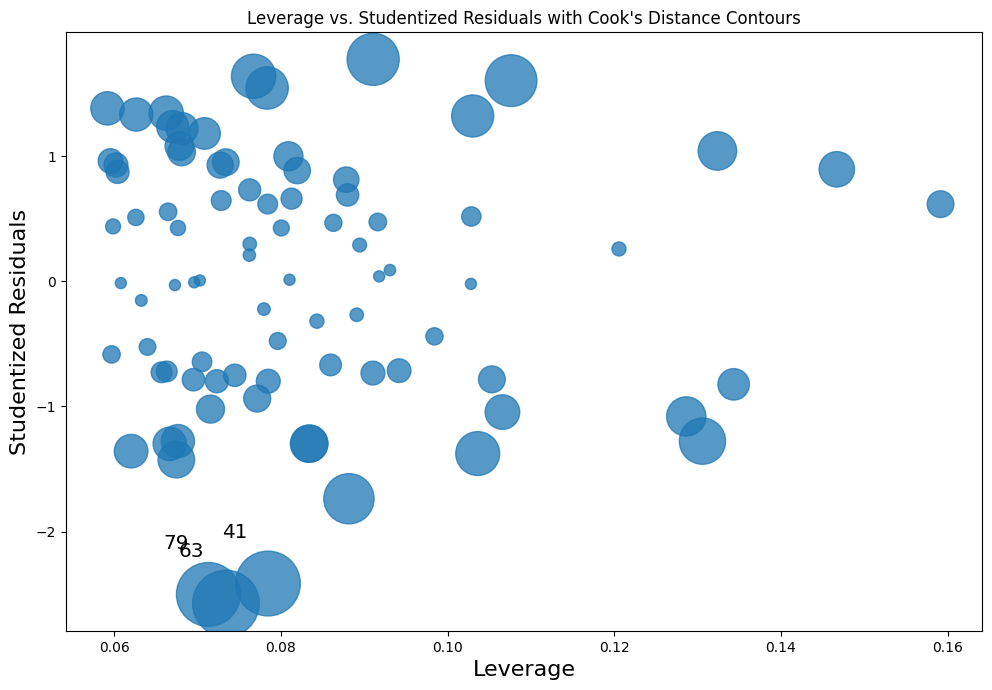

In [62]:
# --- 4. Visualization of Influential Points ---
# Leverage vs. Normalized Residuals plot with Cook's Distance contours
fig, ax = plt.subplots(figsize=(10, 7))
fig = influence.plot_influence(ax=ax)
fig.tight_layout(pad=1.0)
plt.title("Leverage vs. Studentized Residuals with Cook's Distance Contours")
plt.show()

In [63]:
influence_df.iloc[41,:]
X_transformed.iloc[41,:]

Intercept         1.000000
C(Region)[T.E]    0.000000
C(Region)[T.N]    0.000000
C(Region)[T.S]    0.000000
C(Region)[T.W]    1.000000
Literacy         -0.873623
Wealth            1.459281
Name: 41, dtype: float64

## Outlier exclusion

In [64]:
# Identify indices to exclude. You might combine criteria (e.g., high Cook's AND high Studentized Residuals)
# For this example, let's exclude points with Cook's Distance > 4/n
outlier_indices = influential_cooks.index.tolist()

if outlier_indices:
    print(f"\n--- Excluding {len(outlier_indices)} outliers ---")
    print(f"Indices to exclude: {outlier_indices}")

    # Create new DataFrame without outliers
    Y_cleaned = y.drop(outlier_indices)
    X_cleaned = X_transformed.drop(outlier_indices)

    print(f"Cleaned dataset shape: {Y_cleaned.shape}")

    # --- 6. Refit the Model with Cleaned Data ---
    model_cleaned = sm.OLS(Y_cleaned, X_cleaned)
    results_cleaned = model_cleaned.fit()

    results = sm.OLS(y, X_transformed).fit()
    print("\n--- OLS Model Summary (After Outlier Exclusion) ---")
    print(results_cleaned.summary())

    # Compare coefficients (optional)
    print("\n--- Comparison of Coefficients ---")
    print("Original Model Coefficients:")
    print(results.params)
    print("\nCleaned Model Coefficients:")
    print(results_cleaned.params)

else:
    print("\nNo outliers identified based on the chosen Cook's Distance threshold. No exclusion performed.")


--- Excluding 3 outliers ---
Indices to exclude: [41, 63, 79]
Cleaned dataset shape: (82, 1)

--- OLS Model Summary (After Outlier Exclusion) ---
                            OLS Regression Results                            
Dep. Variable:                Lottery   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                     10.80
Date:                Thu, 12 Jun 2025   Prob (F-statistic):           1.25e-08
Time:                        17:33:55   Log-Likelihood:                -352.16
No. Observations:                  82   AIC:                             718.3
Df Residuals:                      75   BIC:                             735.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|     

# Visualizations

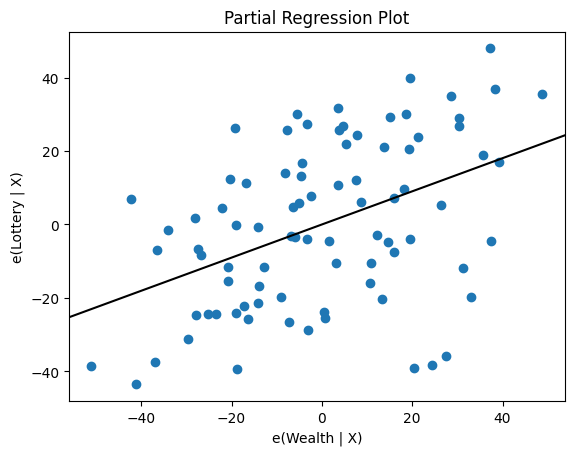

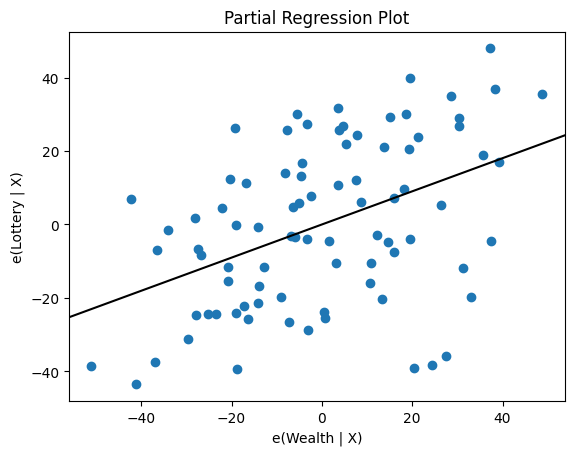

In [65]:
sm.graphics.plot_partregress('Lottery', 'Wealth', ['Region', 'Literacy'],
                             data=df, obs_labels=False)